# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: FinGPT
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\FinGPT.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\FinGPT.sqlite
Closed event type id: 71


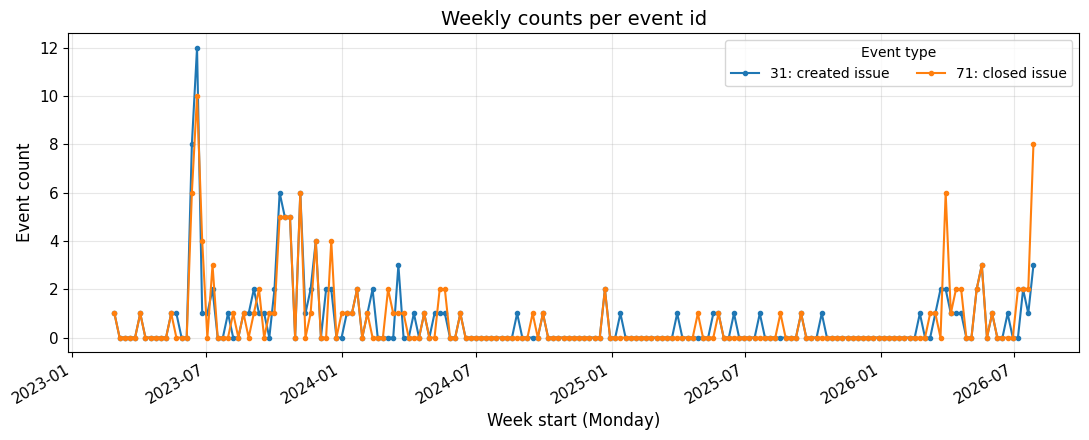

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinGPT\weekly_open_closed_summary.csv


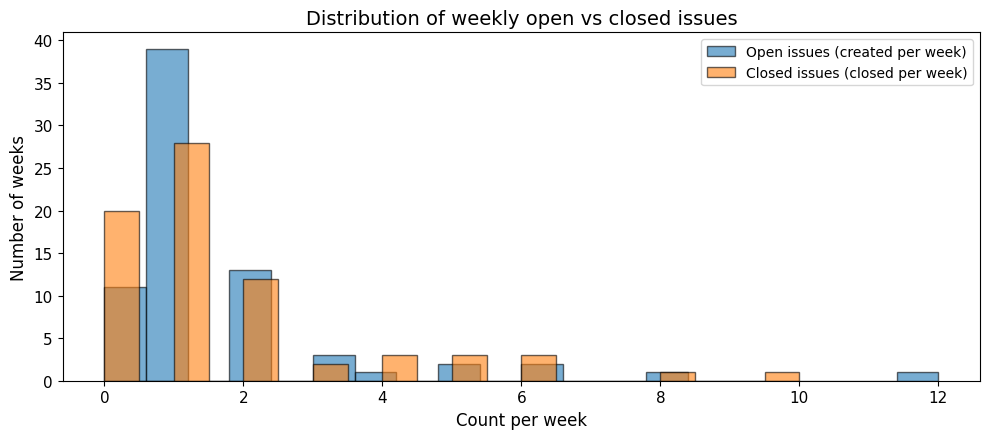

,Open issues (weekly created),Closed issues (weekly closed)
count,73.00,73.00
mean,1.64,1.66
std,1.92,2.00
min,0.00,0.00
25%,1.00,0.00
50%,1.00,1.00
75%,2.00,2.00
max,12.00,10.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("FinGPT")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 4 rolling-IQR anomalies for event_type_id=71.
Joined title attribute rows: 121 of 121 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinGPT\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2023-10-09,5,True,high,0.666667,-2.0,4.0,5,5,P4,documentation,Weekly closures show a slightly beyond-typical...,rule_based,0.950000,"[closed (#90), closed (#96), closed (#91), clo...","[Update FinGPT-RAG/README.md, Update instructi..."
1,2026-03-30,6,True,high,3.500000,-1.5,2.5,6,6,P2,runtime stability,Weekly closures show a well beyond-typical spi...,rule_based,0.844000,"[closed (#221), closed (#224), closed (#220), ...",[fix: pin bitsandbytes and add missing deps fo...
2,2026-05-18,3,True,high,0.500000,-1.5,2.5,3,3,P3,unknown area,Weekly closures show a slightly beyond-typical...,rule_based,0.950000,"[closed (#243), closed (#242), closed (#241)]",[Continuous enhancement: add volatility compre...
3,2026-07-27,8,True,high,1.500000,-3.0,5.0,8,8,P2,runtime stability,Weekly closures show a clearly beyond-typical ...,rule_based,0.764481,"[closed (#204), closed (#260), closed (#258), ...","[example test code on huggingface doesnt work,..."


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2023-10-09,5865
1,2023-10-09,5891
2,2023-10-09,5917
3,2023-10-09,6072
4,2023-10-09,6106


## 4. Anomaly plots


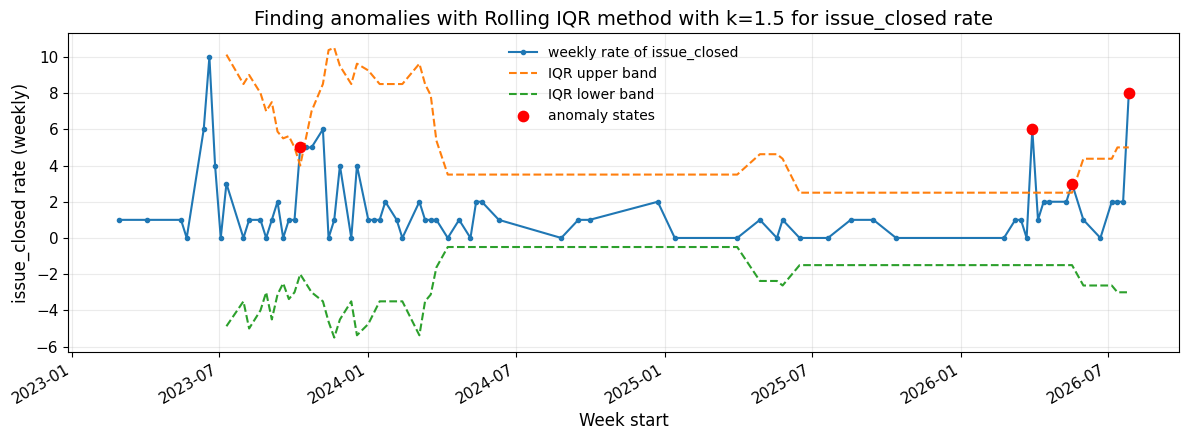

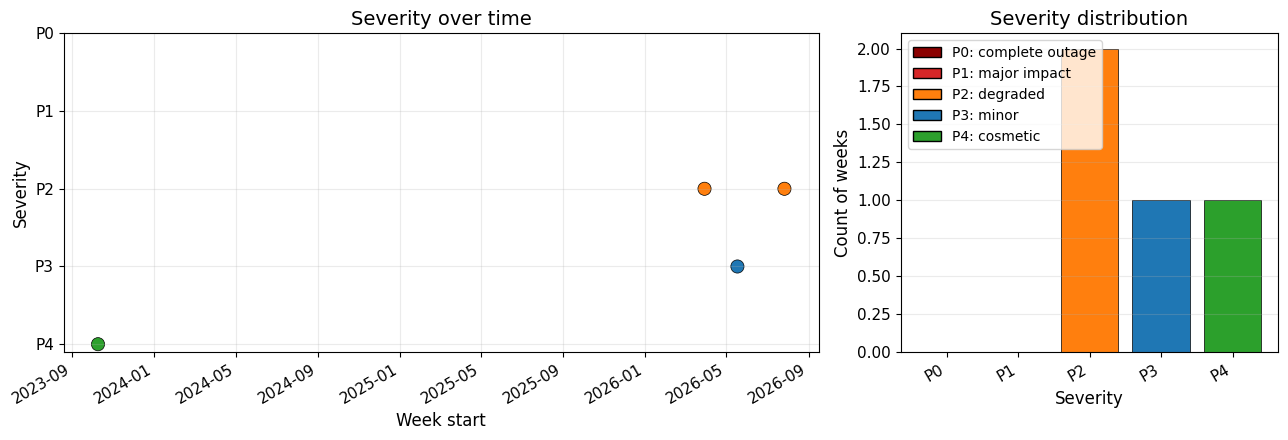

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


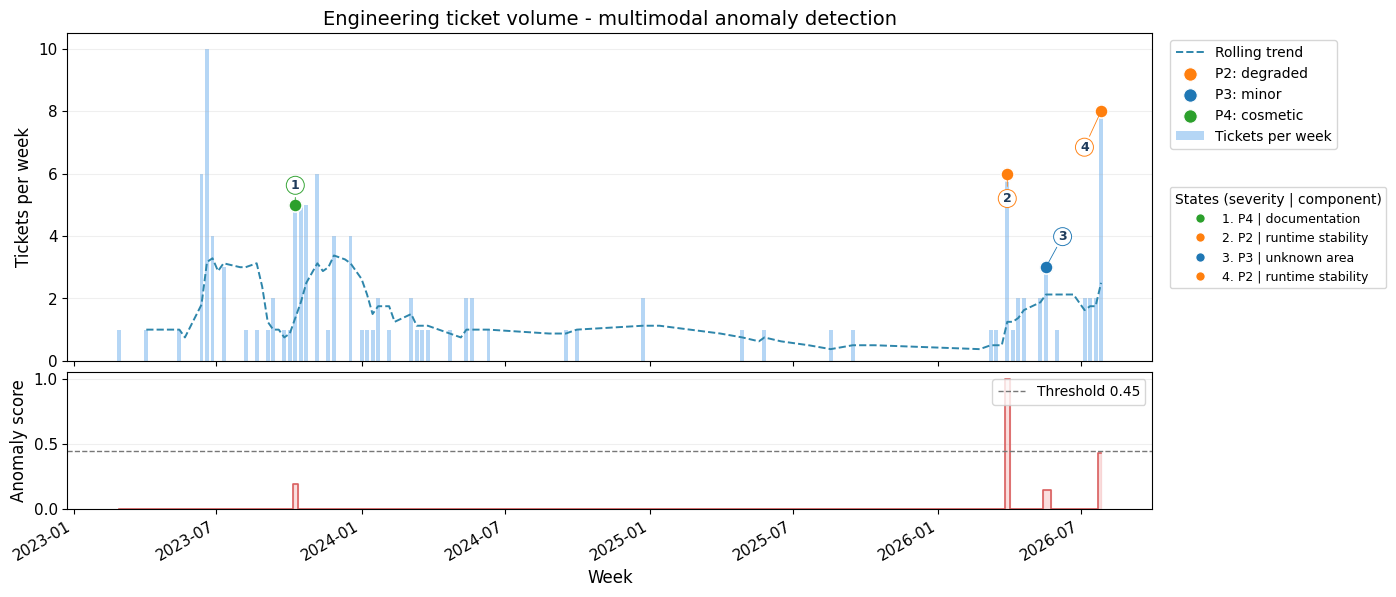

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


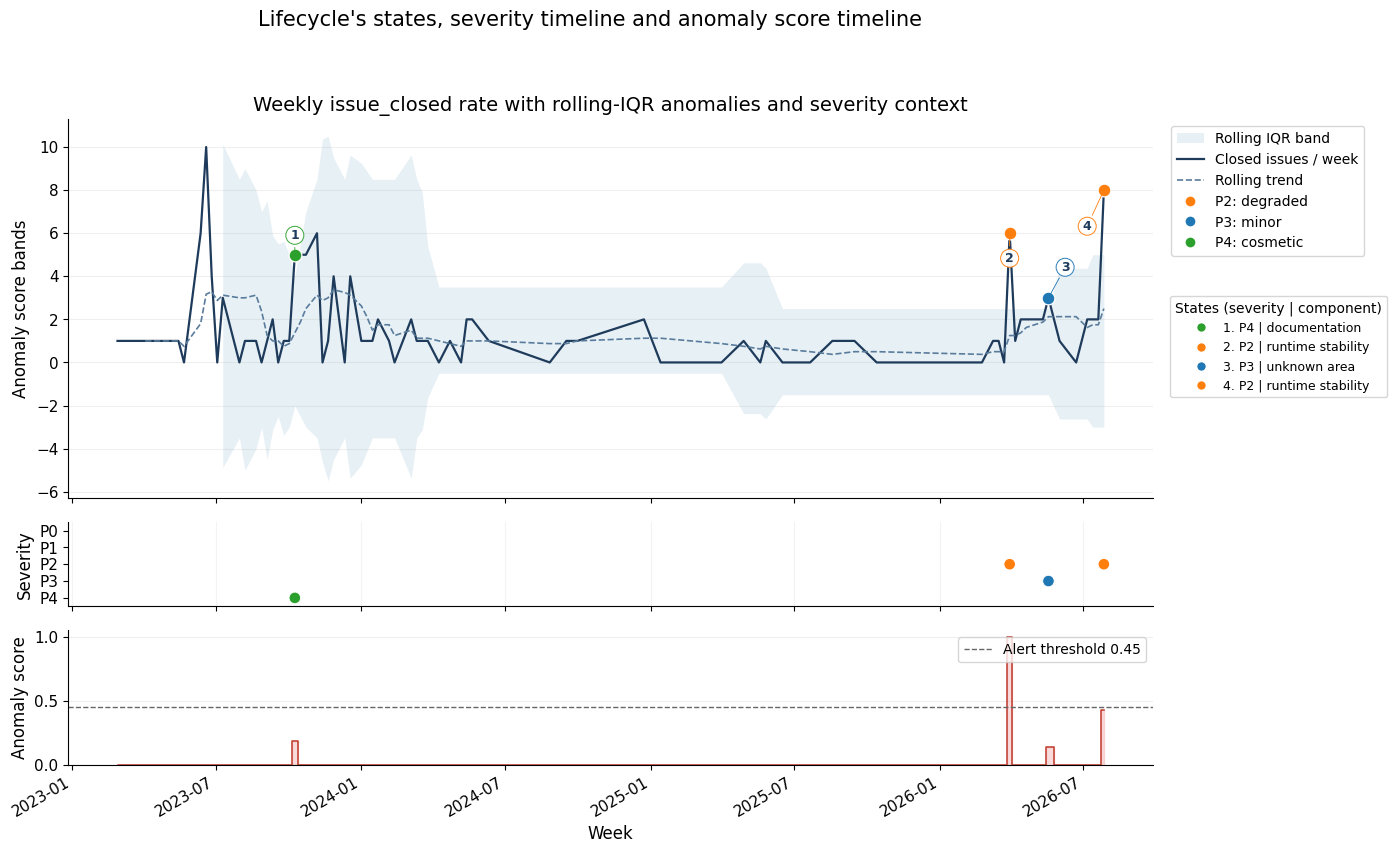

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/FinGPT')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 4 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinGPT\commit_context.csv
commit_typeclass_per_week summary: 4 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.000
  bug_fixes     0.083
  tech_debt     0.000
  docs          0.167
  other         0.750

Mean category ratios by anomaly_direction:
  [high] feature_work=0.000  bug_fixes=0.083  tech_debt=0.000  docs=0.167  other=0.750

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\FinGPT\commit_typeclass_per_week.csv


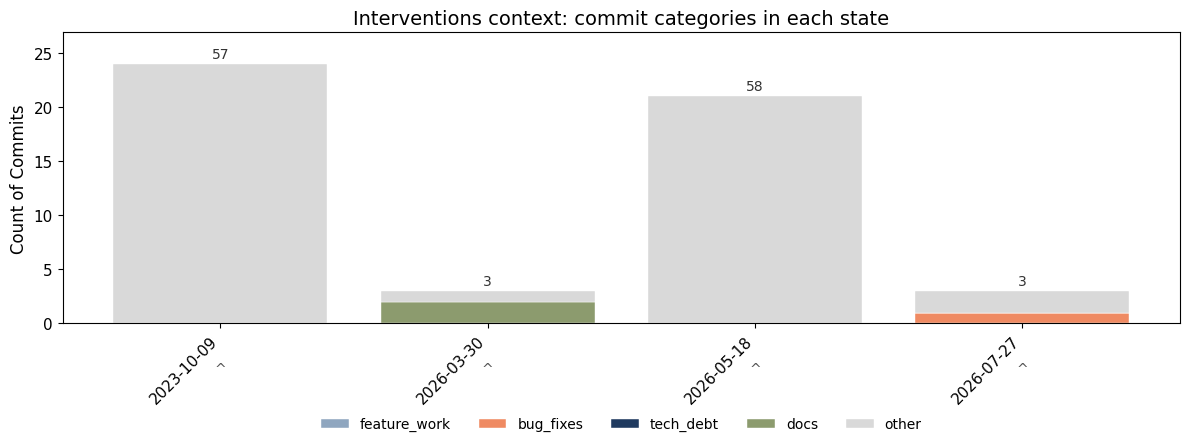

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/FinGPT')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 1139 events, 120 cases
  case:concept:name concept:name            time:timestamp
0              1015    committed 2026-05-14 16:04:50+00:00
1              1015    committed 2026-05-14 16:04:50+00:00
2              1015    committed 2026-05-14 16:04:50+00:00
3              1015    committed 2026-05-14 16:04:50+00:00
4              1015    committed 2026-05-14 16:04:50+00:00
5              1015    committed 2026-05-14 16:04:51+00:00
6              1015    committed 2026-05-14 16:04:51+00:00
7              1015    committed 2026-05-14 16:04:51+00:00
8              1015    committed 2026-05-14 16:04:51+00:00
9              1015    committed 2026-05-14 16:04:51+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 263 rows, 22 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 12 -> 9 cases | 176 -> 53 events
Whole: 63 -> 59 cases | 473 -> 302 events
Random control (rebuilt): 9 cases | 38 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 7/7 [00:00<00:00, 1810.45it/s]


Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
               log_name         discovery_method  distinct_traces  \
0   random_case_control            alpha_classic                7   
1            vitalizing            alpha_classic                8   
2                 whole            alpha_classic               37   
3   random_case_control       heuristics_dep_0.6                7   
4            vitalizing       heuristics_dep_0.6                8   
5                 whole       heuristics_dep_0.6               37   
6   random_case_control       heuristics_dep_0.7                7   
7            vitalizing       heuristics_dep_0.7                8   
8                 whole       heuristics_dep_0.7               37   
9   random_case_control       heuristics_dep_0.8                7   
10           vitalizing       heuristics_dep_0.8                8   
11                whole       heuristics_dep_0.8               37   
12  random_case_contro

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,7,0.501205,0.731051,0.272727,0.397254,28.0,1.0,1.000000,ok,None
1,vitalizing,alpha_classic,8,0.378896,0.722493,0.314607,0.438340,56.0,5.0,0.600000,ok,None
2,whole,alpha_classic,37,0.553484,0.609646,0.216014,0.318998,103.0,23.0,0.389474,ok,None
3,random_case_control,heuristics_dep_0.6,7,0.337257,0.917075,0.626374,0.744348,70.0,3.0,0.600000,ok,None
4,vitalizing,heuristics_dep_0.6,8,0.262060,1.000000,0.593103,0.744589,114.0,0.0,0.641026,ok,None


## 10. Utility figures


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinGPT\clean_log_f_score_grouped_bars.{png,pdf}


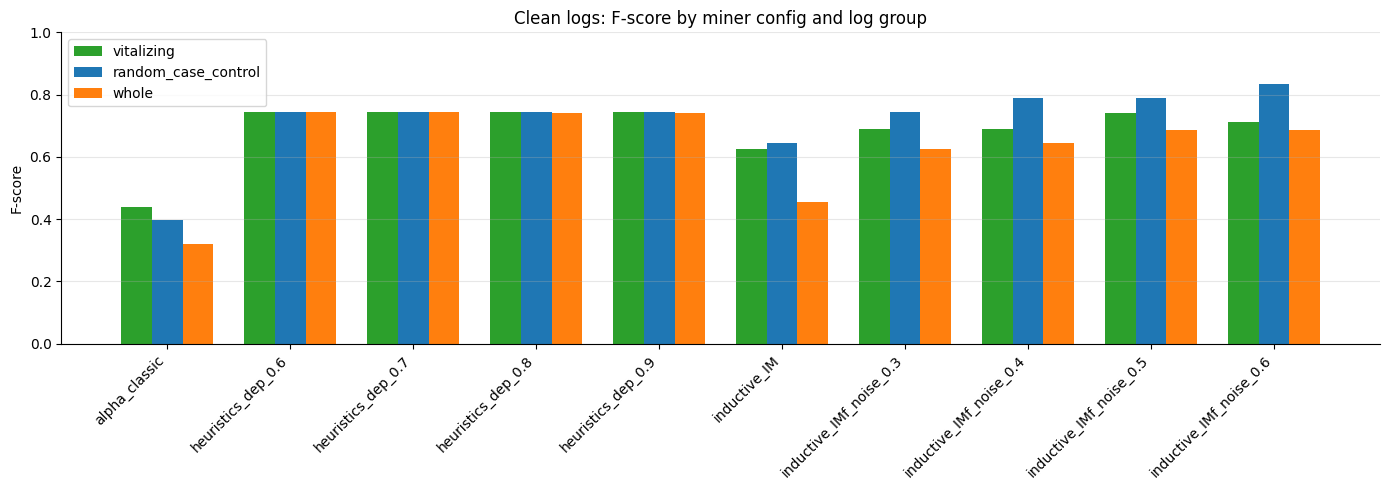

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinGPT\clean_log_fitness_precision.{png,pdf}


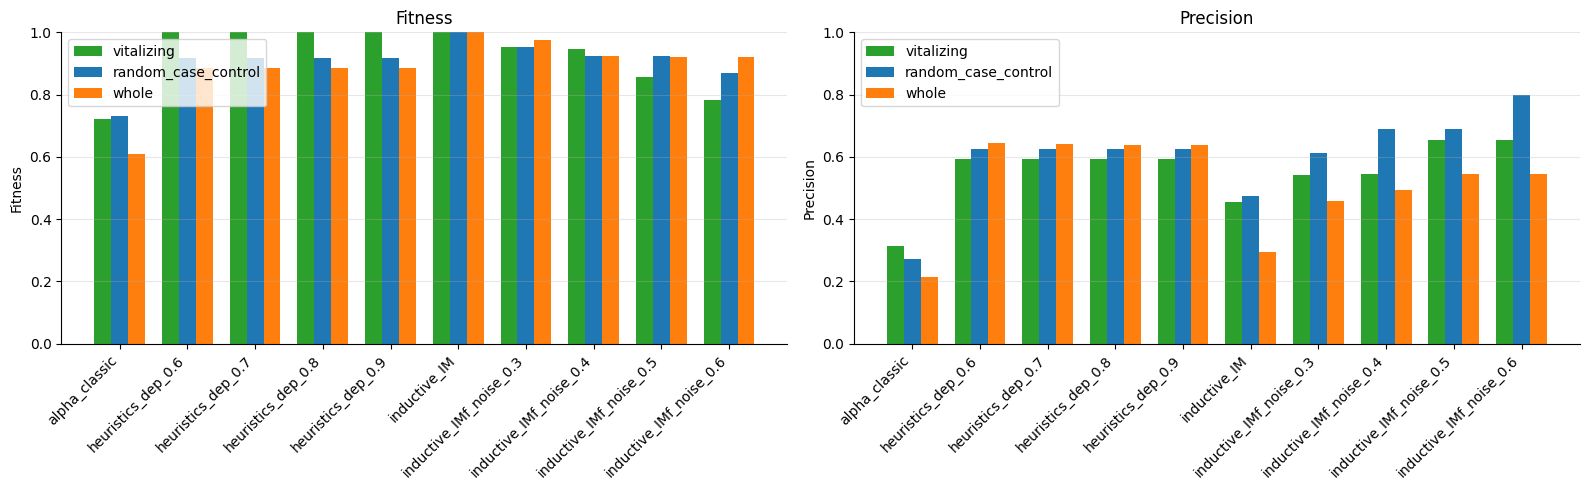

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinGPT\clean_log_complexity.{png,pdf}


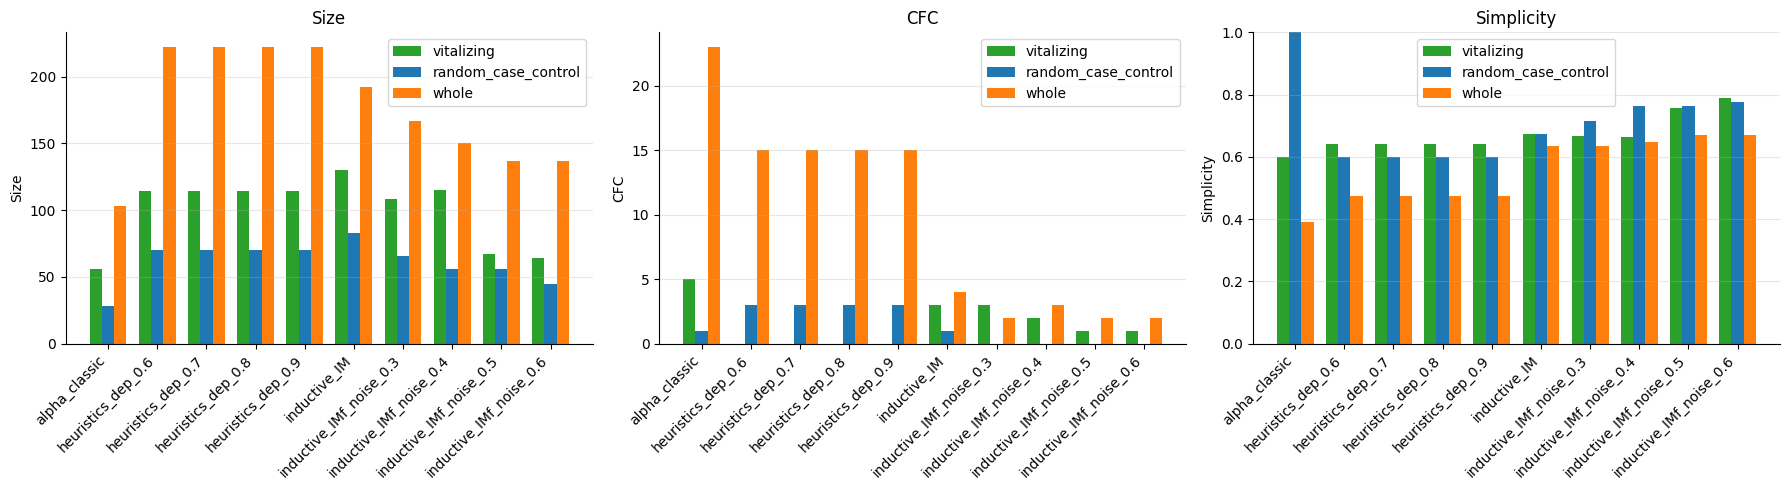

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinGPT\clean_log_threshold_sensitivity.{png,pdf}


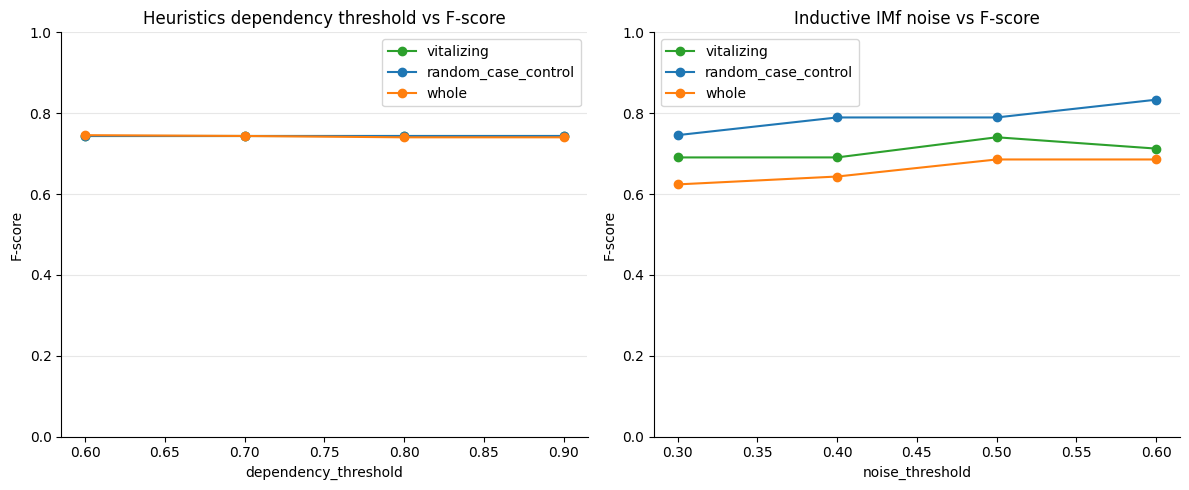

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\FinGPT\clean_log_f_score_slopegraph.{png,pdf}


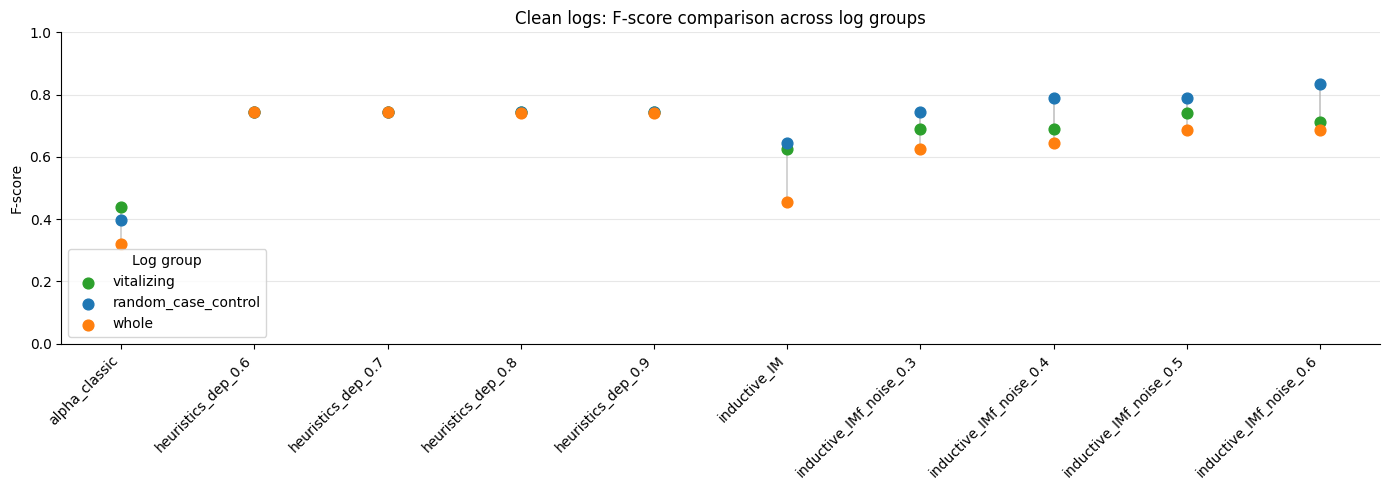

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.6  heuristics_dep_0.7  \
 log_name                                                                     
 random_case_control       0.397254            0.744348            0.744348   
 vitalizing                0.438340            0.744589            0.744589   
 whole                     0.318998            0.745555            0.743629   
 
 discovery_method     heuristics_dep_0.8  heuristics_dep_0.9  inductive_IM  \
 log_name                                                                    
 random_case_control            0.744348            0.744348      0.643564   
 vitalizing                     0.744589            0.744589      0.625455   
 whole                          0.740286            0.740286      0.456140   
 
 discovery_method     inductive_IMf_noise_0.3  inductive_IMf_noise_0.4  \
 log_name                                                                
 random_case_control                 0.74

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 8/8 [00:00<00:00, 482.63it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
          discovery_method  fitness_mean  fitness_std  fitness_cv  \
0            alpha_classic      0.786331     0.065145    0.082847   
1       heuristics_dep_0.6      0.929239     0.029458    0.031701   
2       heuristics_dep_0.7      0.929239     0.029458    0.031701   
3       heuristics_dep_0.8      0.929239     0.029458    0.031701   
4       heuristics_dep_0.9      0.929239     0.029458    0.031701   
5             inductive_IM      1.000000     0.000000    0.000000   
6  inductive_IMf_noise_0.3      0.969187     0.020480    0.021131   
7  inductive_IMf_noise_0.4      0.946215     0.048796    0.051570   
8  inductive_IMf_noise_0.5      0.922024     0.049739    0.053945   
9  inductive_IMf_noise_0.6      0.904405     0.058324    0.064488   

   precision_mean  precision_std  precision_cv  f_score_mean  f_score_std  \
0        0.356057       0.253460      0.711852   

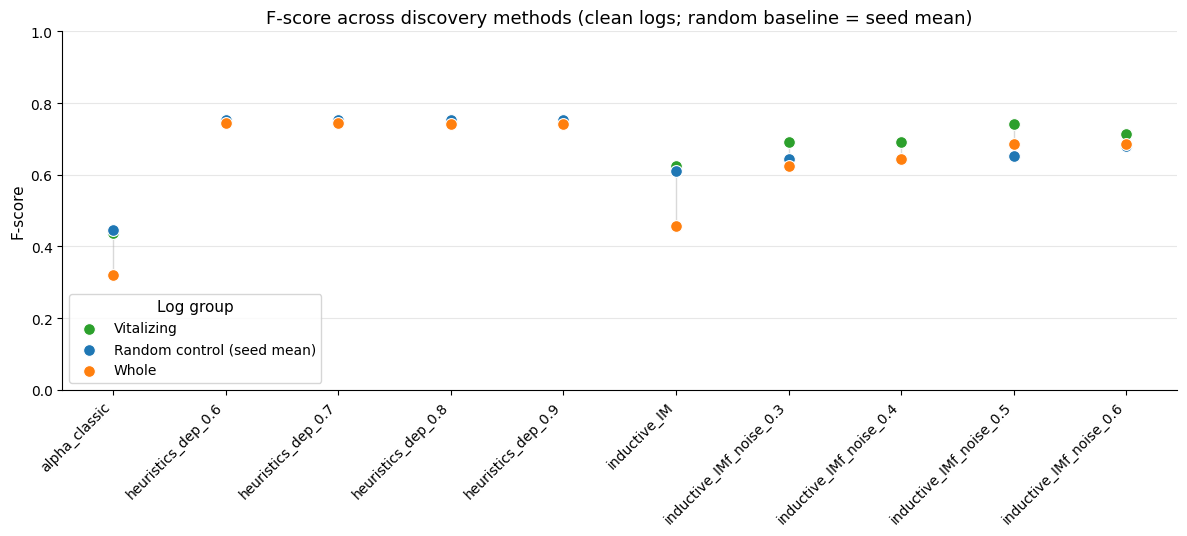

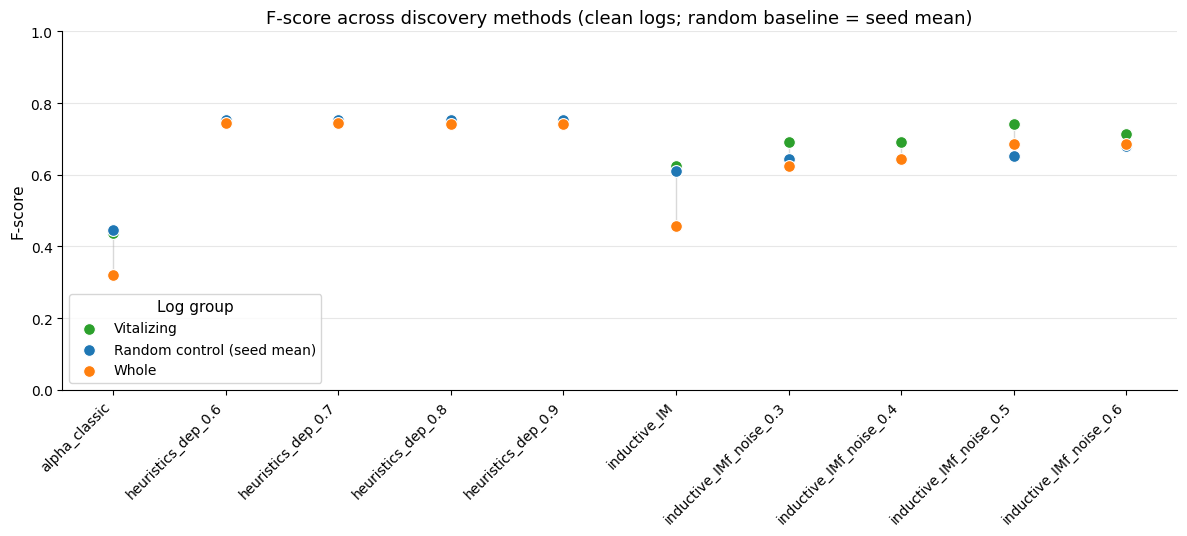

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)


## 12. Log complexity metrics (process-complexity / EPA)


In [ ]:
from functions.complexity_metrics import compute_log_complexity_table

log_complexity_similarity_table = compute_log_complexity_table(clean_log_groups_eventlog, cfg)
log_complexity_similarity_table
